scikit-learnが分散処理をする可能性があるので、実行時間は信頼できなくなるかも。

In [1]:
from datetime import datetime
import pickle
import os
from multiprocessing import Pool

import numpy as np
import pandas as pd
import lingam
from scipy.stats import kendalltau

import matplotlib.pyplot as plt

np.random.seed(0)

## Low dimensional consistency

In [2]:
def make_dag_and_errors(n_nodes, sample_size, J=3):
    dag = np.zeros((n_nodes, n_nodes))
    errors = None
    
    # For each node v
    for v in range(n_nodes):        
        #  select the number of parents
        num_pa = np.random.choice(np.arange(min(n_nodes, J)))

        if v - 1 >= 0:
            # We include edge (v − 1, v) to ensure that the ordering is unique
            dag[v, v - 1] = np.random.choice([-1, 1]) * np.random.uniform(0.5, 1)

        # The remaining parents are selected uniformly from [v − 2]
        candidates = np.arange(v - 1)
        if len(candidates) == 0:
            continue

        # num_paは最低3あるが、例えば2列目の変数の候補は[0]しかない。(1は順序を一意に保つために使う)
        # そのためlen(candidate)との大小関係もチェックが要る。
        pa = np.random.choice(candidates, size=min(num_pa, len(candidates)), replace=False)

        # the corresponding edge weights are set to +-1/5
        # どちら？範囲？選択？ Unifromだと0に近い部分が頻発する羽目になるのでおかしくないか？
        #dag[v, pa] = np.random.uniform(-1/5, 1/5, size=len(pa))
        dag[v, pa] = np.random.choice([-1/5, 1/5], size=len(pa))

    # The n error terms for variable v are generated by selecting σv ∼ unif(.8, 1)
    # drawing εvi ∼ σvunif(−√3,√3).
    errors = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(sample_size, n_nodes))
    errors = errors * np.random.uniform(0.8, 1, size=n_nodes)

    return dag, errors

### テスト用関数

ループをマルチプロセス化できるようにした。

In [3]:
def n_list_func_impl(p):
    return [10 * p, 50 * p]

def test_impl(args):
    p, n, i, seed, disable_direct, make_func = args
    
    np.random.seed(seed)
    
    true_order = np.arange(p)

    dag, errors = make_func(p, n)
    X = (np.linalg.pinv(np.eye(p) - dag) @ errors.T).T

    # evals high_im
    high_d_start = datetime.now()

    high_d_model = lingam.HighDimDirectLiNGAM()
    high_d_model.fit(X)

    elapse_high_d = (datetime.now() - high_d_start).total_seconds()

    eval_high_d = kendalltau(high_d_model.causal_order_, true_order).statistic

    # evals normal
    if disable_direct:
        eval_normal = None
    else:
        normal_model = lingam.DirectLiNGAM()
        normal_model.fit(X)

        eval_normal = kendalltau(normal_model.causal_order_, true_order).statistic
        
    print(f"\r{i:8d}", end="")

    return i, eval_high_d, elapse_high_d, eval_normal
            
def run_test(p_list=None, n_list_func=None, loop_num=500, make_func=None, disable_direct=False):
    if p_list is None:
        p_list = np.arange(5, 25, 5, dtype=int)

    if n_list_func is None:
        n_list_func = n_list_func_impl

    if make_func is None:
        make_func = make_dag_and_errors
    
    results = {}
    
    for p in p_list:
        for n in n_list_func(p):
            print(f"+p={p:4d}, n={n:4d}")
            
            start = datetime.now()
            
            seeds = np.random.randint(0, high=0xFFFFFFFF, size=loop_num)
            args = {(p, n, i, seed, disable_direct, make_func) for i, seed in enumerate(seeds)}
            
            # マルチプロセスの有効無効
            if True:
                with Pool(24) as pool:
                    result = pool.map(test_impl, args)
            else:
                result = []
                for arg in args:
                    result.append(test_impl(arg))
                
            result = sorted(result, key=lambda e: e[0])
            indices, eval_high_d, elapse_high_d, eval_normal = np.array(result).T
            
            results[(n, p)] = {
                "high_d": eval_high_d,
                "normal": eval_normal,
                "elapse_high_d": elapse_high_d,
            }
            
            elapse = (datetime.now() - start).total_seconds()
            
            print(f"\r-p={p:4d}, n={n:4d}, elapse={elapse:.2f}sec")

    max_p = max(p_list)
    max_n = max(n_list_func(max_p))
    fname = datetime.now().strftime('%Y%m%d%H%M%S') + f"_{max_p}_{max_n}_{loop_num}.bin"

    with open(fname, "wb") as f:
        pickle.dump(results, f)
    print("saved:", fname)
        
    return results

if True:
    results = run_test(loop_num=500)
else:
    # 3000sec
    with open("20240614193139_20_1000_500.bin", "rb") as f:
        results = pickle.load(f)

+p=   5, n=  50
-p=   5, n=  50, elapse=0.97sec
+p=   5, n= 250
-p=   5, n= 250, elapse=1.04sec
+p=  10, n= 100
-p=  10, n= 100, elapse=6.64sec
+p=  10, n= 500
-p=  10, n= 500, elapse=8.41sec
+p=  15, n= 150
-p=  15, n= 150, elapse=23.01sec
+p=  15, n= 750
-p=  15, n= 750, elapse=74.28sec
+p=  20, n= 200
-p=  20, n= 200, elapse=54.02sec
+p=  20, n=1000
-p=  20, n=1000, elapse=218.82sec
saved: 20240617122327_20_1000_500.bin


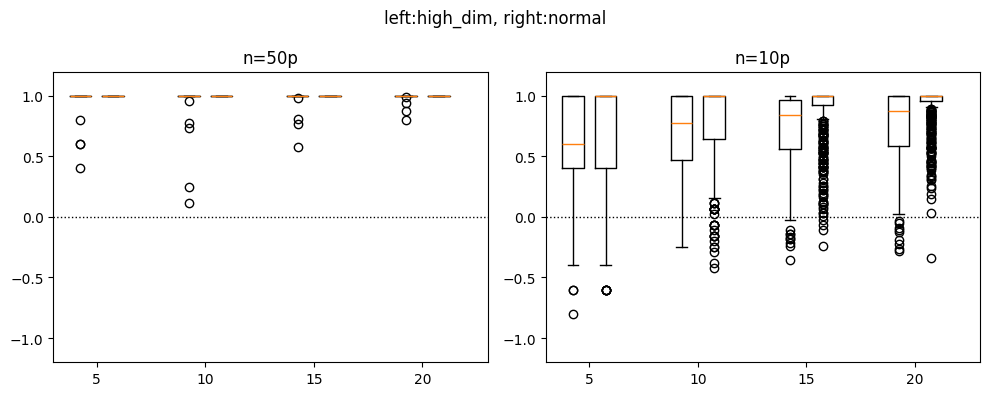

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for (n, p), evals in results.items():
    ax = axes[0] if n / p == 50.0 else axes[1]
    
    ax.boxplot(
        evals["high_d"],
        positions=[p - 0.75],
        widths=[1],
    )

    ax.boxplot(
        evals["normal"],
        positions=[p + 0.75],
        widths=[1],
    )
    
axes[0].set_title("n=50p")
axes[1].set_title("n=10p")
axes[0].set_ylim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)
axes[0].set_xlim(3, 23)
axes[1].set_xlim(3, 23)
axes[0].axhline(0, color="black", lw=1, ls="dotted")
axes[1].axhline(0, color="black", lw=1, ls="dotted")
axes[0].set_xticks([5, 10, 15, 20])
axes[1].set_xticks([5, 10, 15, 20])
axes[0].set_xticklabels([5, 10, 15, 20])
axes[1].set_xticklabels([5, 10, 15, 20])
plt.suptitle("left:high_dim, right:normal")
plt.tight_layout()

## High dimensional consistency

In [5]:
def make_dag_and_errors2(n_nodes, sample_size, J=2):
    # HubGraph
    dag = np.zeros((n_nodes, n_nodes))
    errors = None
    
    # We first consider random DAGs and data generated as before, but with J = 2
    # 先ほどと同じ。Jの値と係数の値の範囲が違う。
    # For each node v
    for v in range(n_nodes):        
        #  select the number of parents
        num_pa = np.random.choice(np.arange(min(n_nodes, J)))

        if v - 1 >= 0:
            # We include edge (v − 1, v) to ensure that the ordering is unique
            dag[v, v - 1] = np.random.choice([-1, 1]) * np.random.uniform(0.65, 1)

        # The remaining parents are selected uniformly from [v − 2]
        candidates = np.arange(v - 1)
        if len(candidates) == 0:
            continue

        pa = np.random.choice(candidates, size=min(num_pa, len(candidates)), replace=False)

        # the corresponding edge weights are set to +-1/5
        # XXX: どちらだろうか
        #dag[v, pa] = np.random.uniform(-1/5, 1/5, size=len(pa))
        dag[v, pa] = np.random.choice([-1/5, 1/5], size=len(pa))
    #display(pd.DataFrame(dag))

    # add hubs
    # 非hubノードはいずれかのハブからのエッジを受けること。対角直下は決まっているので手をださないこと。
    for v in np.arange(3, n_nodes):
        # ハブの選択と係数の作成
        coefs = np.zeros(3)
        
        if v == 3:
            # 変数3のみ特別処理。変数2との接続は強制なのでそれ以外から選ぶ。
            index = np.random.choice([0, 1])
        else:
            index = np.random.choice([0, 1, 2])
            
        # XXX: ±1/5とはどちらだろう？
        #coefs[index] = np.random.uniform(-1/5, 1/5)
        coefs[index] = np.random.choice([-1/5, 1/5])

        # すでに係数が設定してあれば、そちらを優先する。coefはdag側が0である部分のみ非ゼロになる。
        filter_ = ~np.isclose(dag[v, :3], 0)
        coefs[filter_] = 0
        
        # フィルタしているので足して設定する
        dag[v, :3] += coefs

    # disturbances
    errors = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(sample_size, n_nodes))
    errors = errors * np.random.uniform(0.8, 1, size=n_nodes)

    return dag, errors

if True:
    dag, errors = make_dag_and_errors2(10, 100)
    display(pd.DataFrame(dag))
    
    # チェック
    for i in range(1000):
        dag, errors = make_dag_and_errors2(10, 10)
        # 対角から上は全部0
        assert (np.triu(dag) == 0).sum(axis=None) == 100
        # 1を超えるものは存在しない
        assert (np.abs(dag) > 1).sum() == 0
        # 非ハブは最低一つのハブを親に持つ。
        assert all((~np.isclose(dag[3:, :3], 0)).sum(axis=1) > 0)

,0,1,2,3,4,5,6,7,8,9
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
1,0.976844,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
2,0.000000,0.974149,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
3,0.000000,0.200000,-0.726979,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
4,-0.200000,0.000000,0.000000,0.705814,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
5,0.000000,-0.200000,0.000000,0.000000,-0.787309,0.000000,0.00000,0.000000,0.000000,0.0
6,0.000000,0.000000,-0.200000,0.000000,0.000000,0.986844,0.00000,0.000000,0.000000,0.0
7,-0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.70275,0.000000,0.000000,0.0
8,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.20000,-0.766472,0.000000,0.0
9,0.000000,0.000000,-0.200000,0.000000,0.200000,0.000000,0.00000,0.000000,0.856161,0.0


In [6]:
p_list = [25, 50, 75, 100]#, 150, 200]
n_list_func = lambda p: [int((3 / 4) * p)]


# random
#results = run_test(p_list=p_list, n_list_func=n_list_func, loop_num=16, make_func=make_dag_and_errors, disable_direct=True)
results = run_test(p_list=None, n_list_func=n_list_func, loop_num=16, make_func=make_dag_and_errors, disable_direct=True)
# hub
#results2 = run_test(p_list=p_list, n_list_func=n_list_func, loop_num=16, make_func=make_dag_and_errors2, disable_direct=True)

+p=   5, n=   3
-p=   5, n=   3, elapse=0.11sec
+p=  10, n=   7
-p=  10, n=   7, elapse=0.24sec
+p=  15, n=  11
-p=  15, n=  11, elapse=0.43sec
+p=  20, n=  15
-p=  20, n=  15, elapse=0.98sec
saved: 20240617122329_20_15_16.bin


(0.0, 125.0)

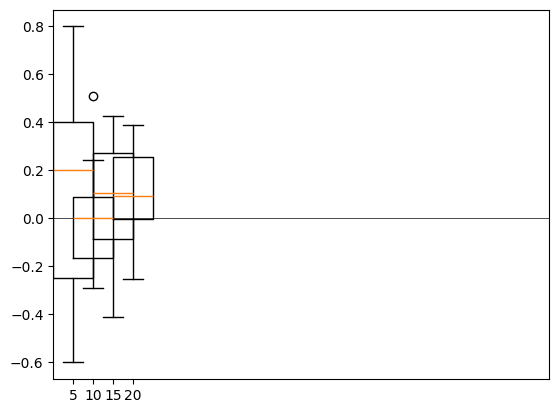

In [7]:
if False:
    with open("20240614195557_100_75_16.bin", "rb") as f:
        reults = pickle.load(f)

for (n, p), evals in results.items():
    
    plt.boxplot(
        evals["high_d"],
        positions=[p],
        widths=[10],
    )
plt.axhline(0, color="black", lw=0.5)
plt.xlim(0, 125)

(0.0, 25.0)

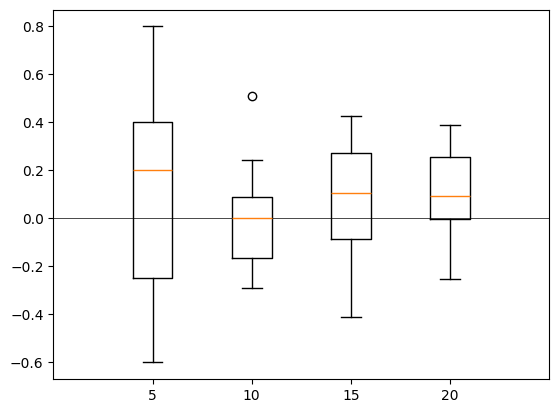

In [8]:
for (n, p), evals in results.items():
    
    plt.boxplot(
        evals["high_d"],
        positions=[p],
        widths=[2],
    )
plt.axhline(0, color="black", lw=0.5)
plt.xlim(0, 25)

In [9]:
p_list = [5, 10, 15, 20]
n_list_func = lambda p: [p, 5* p, 10 * p, 15*p, 20 * p]

results = run_test(p_list=p_list, n_list_func=n_list_func, loop_num=20, make_func=make_dag_and_errors, disable_direct=True)

+p=   5, n=   5
-p=   5, n=   5, elapse=0.12sec
+p=   5, n=  25
-p=   5, n=  25, elapse=0.14sec
+p=   5, n=  50
-p=   5, n=  50, elapse=0.11sec
+p=   5, n=  75
-p=   5, n=  75, elapse=0.12sec
+p=   5, n= 100
-p=   5, n= 100, elapse=0.11sec
+p=  10, n=  10
-p=  10, n=  10, elapse=0.22sec
+p=  10, n=  50
-p=  10, n=  50, elapse=0.22sec
+p=  10, n= 100
-p=  10, n= 100, elapse=0.25sec
+p=  10, n= 150
-p=  10, n= 150, elapse=0.24sec
+p=  10, n= 200
-p=  10, n= 200, elapse=0.26sec
+p=  15, n=  15
-p=  15, n=  15, elapse=0.53sec
+p=  15, n=  75
-p=  15, n=  75, elapse=0.51sec
+p=  15, n= 150
-p=  15, n= 150, elapse=0.55sec
+p=  15, n= 225
-p=  15, n= 225, elapse=0.60sec
+p=  15, n= 300
-p=  15, n= 300, elapse=0.60sec
+p=  20, n=  20
-p=  20, n=  20, elapse=1.05sec
+p=  20, n= 100
-p=  20, n= 100, elapse=1.09sec
+p=  20, n= 200
-p=  20, n= 200, elapse=1.17sec
+p=  20, n= 300
-p=  20, n= 300, elapse=1.24sec
+p=  20, n= 400
-p=  20, n= 400, elapse=1.27sec
saved: 20240617122340_20_400_20.bin


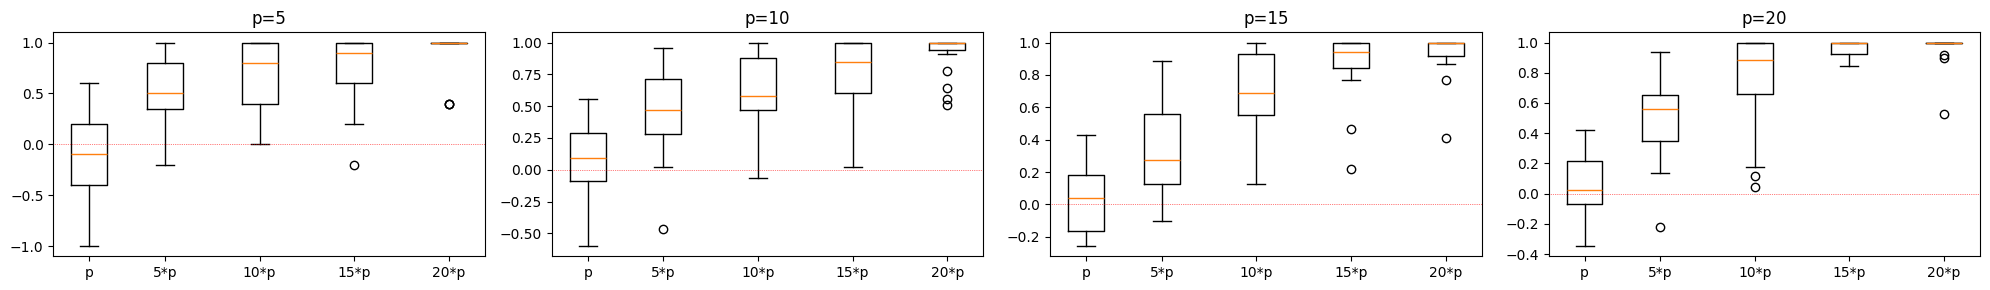

In [10]:
p_list = [5, 10, 15, 20]

fig, axes = plt.subplots(1, len(p_list), figsize=(20, 3))

for ax, p in zip(axes, p_list):
    n_list = n_list_func(p)
    
    w = 0.1 * (n_list[-1] - n_list[0])
    
    for n in n_list:
        evals = results[(n, p)]

        ax.boxplot(
            evals["high_d"],
            positions=[n],
            widths=[w],
        )
        
    ax.set_xlim(n_list[0] - w, n_list[-1] + w)
    ax.set_title(f"p={p}")
    
    ax.set_xticks(n_list)
    ax.set_xticklabels(["p", "5*p", "10*p", "15*p", "20*p"])

    ax.axhline(0, color="red", lw=0.5, ls="dotted")
plt.tight_layout()
plt.show()

+p=   5, n=  50
-p=   5, n=  50, elapse=0.12sec
+p=  10, n= 100
-p=  10, n= 100, elapse=0.29sec
+p=  15, n= 150
-p=  15, n= 150, elapse=0.63sec
+p=  20, n= 200
-p=  20, n= 200, elapse=1.36sec
+p=  25, n= 250
-p=  25, n= 250, elapse=2.62sec
+p=  30, n= 300
-p=  30, n= 300, elapse=4.88sec
saved: 20240617122350_30_300_24.bin


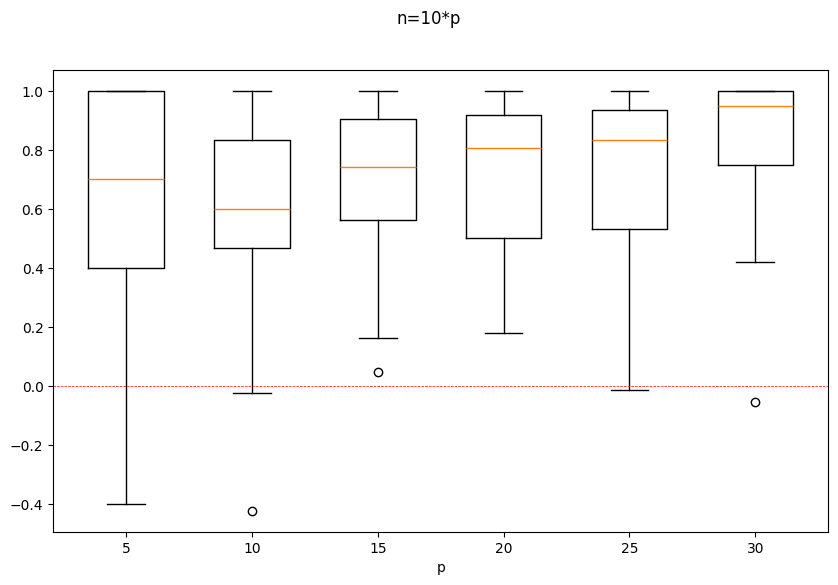

In [11]:
p_list = [5, 10, 15, 20, 25, 30]
n_list_func = lambda p: [10 * p]

results2 = run_test(p_list=p_list, n_list_func=n_list_func, loop_num=24, make_func=make_dag_and_errors, disable_direct=True)

plt.figure(figsize=(10, 6))

for (n, p), evals in results2.items():
    plt.boxplot(
        evals["high_d"],
        positions=[p],
        widths=[3],
    )
plt.axhline(0, color="red", lw=0.5, ls="dashed")
plt.xlabel("p")
plt.suptitle("n=10*p")
plt.show()

+p=  10, n=  50
-p=  10, n=  50, elapse=0.25sec
+p=  30, n= 150
-p=  30, n= 150, elapse=4.48sec
+p=  50, n= 250
-p=  50, n= 250, elapse=26.42sec
+p=  70, n= 350
-p=  70, n= 350, elapse=90.61sec
+p=  90, n= 450
-p=  90, n= 450, elapse=187.07sec
saved: 20240617122859_90_450_24.bin


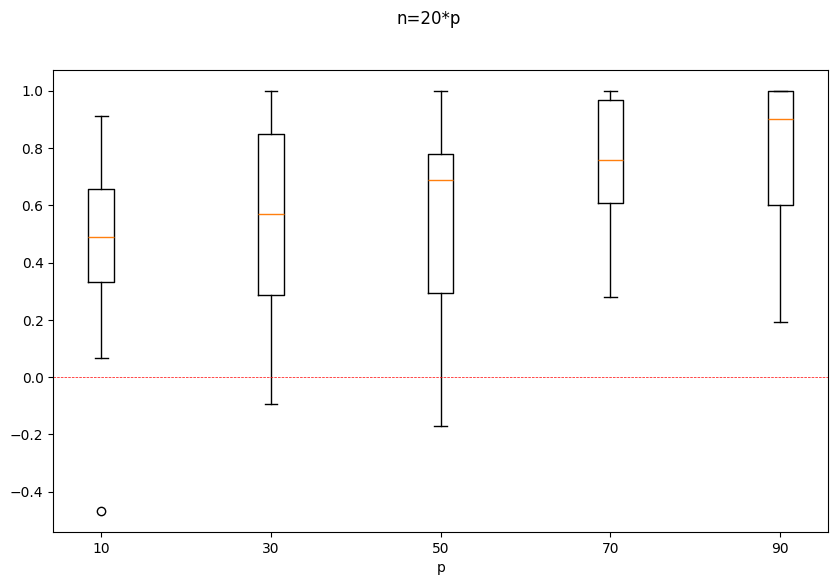

In [12]:
p_list = [10, 30, 50, 70, 90]
n_list_func = lambda p: [5 * p]

results2 = run_test(p_list=p_list, n_list_func=n_list_func, loop_num=24, make_func=make_dag_and_errors, disable_direct=True)

plt.figure(figsize=(10, 6))

for (n, p), evals in results2.items():
    plt.boxplot(
        evals["high_d"],
        positions=[p],
        widths=[3],
    )
plt.axhline(0, color="red", lw=0.5, ls="dashed")
plt.xlabel("p")
plt.suptitle("n=20*p")
plt.show()

In [13]:
p_list = [25, 50, 75, 100, 125, 150, 200]
n_list_func = lambda p: [int(3/ 4 * p)]

results = run_test(p_list=p_list, n_list_func=n_list_func, loop_num=20, make_func=make_dag_and_errors, disable_direct=True)

+p=  25, n=  18
-p=  25, n=  18, elapse=1.44sec
+p=  50, n=  37
-p=  50, n=  37, elapse=15.23sec
+p=  75, n=  56
-p=  75, n=  56, elapse=71.53sec
+p= 100, n=  75
-p= 100, n=  75, elapse=170.13sec
+p= 125, n=  93
-p= 125, n=  93, elapse=320.02sec
+p= 150, n= 112
-p= 150, n= 112, elapse=535.48sec
+p= 200, n= 150
-p= 200, n= 150, elapse=1246.92sec
saved: 20240617140329_200_150_20.bin


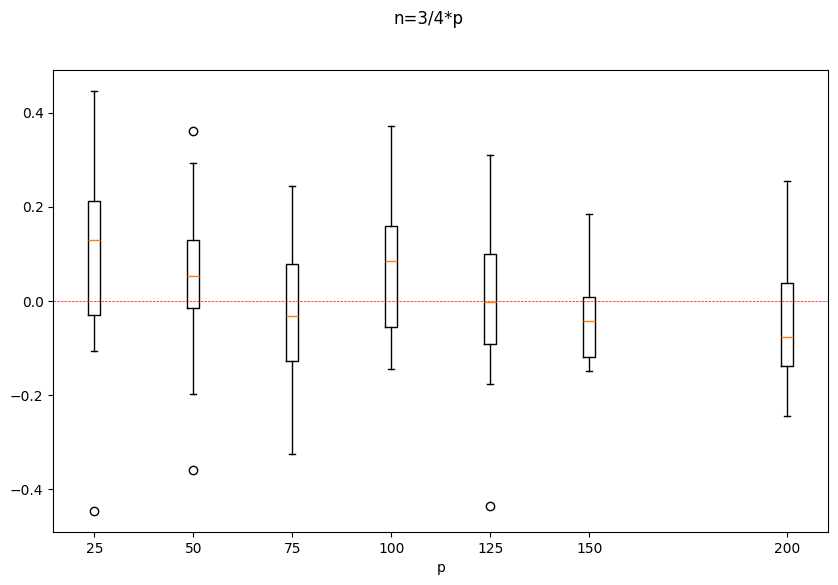

In [15]:
plt.figure(figsize=(10, 6))

for (n, p), evals in results.items():
    plt.boxplot(
        evals["high_d"],
        positions=[p],
        widths=[3],
    )
plt.axhline(0, color="red", lw=0.5, ls="dashed")
plt.xlabel("p")
plt.suptitle("n=3/4*p")
plt.show()